In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sqlalchemy import create_engine, text
from scipy import stats

engine = create_engine('postgresql://vatsalj05@localhost:5432/sentineliq')

with open('../models/sentineliq_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('../models/features.pkl', 'rb') as f:
    features = pickle.load(f)
with open('../models/platt_scaler.pkl', 'rb') as f:
    platt_scaler = pickle.load(f)

with engine.connect() as conn:
    df = pd.read_sql("SELECT * FROM transactions_raw", conn)

# We don't have real timestamps so we simulate realistic time windows
# using transactionid as a proxy for order (higher ID = more recent)
# This is valid — transaction IDs are typically sequential
df_sorted = df.sort_values('transactionid').reset_index(drop=True)

# Split into 8 monthly windows
n_windows = 8
window_size = len(df_sorted) // n_windows
df_sorted['time_window'] = np.clip(df_sorted.index // window_size, 0, n_windows-1)
df_sorted['month_label'] = df_sorted['time_window'].map(
    {i: f"Month {i+1}" for i in range(n_windows)}
)

# Simulate drift — inject increasingly fraudulent behaviour in later windows
# This mimics a real-world scenario where fraud patterns evolve over time
np.random.seed(42)
for i in range(4, n_windows):  # drift starts at month 5
    drift_mask = (df_sorted['time_window'] == i)
    drift_intensity = (i - 3) * 0.15  # increases each month
    
    # Simulate: transaction amounts spike (new fraud pattern)
    df_sorted.loc[drift_mask, 'transactionamt'] *= (1 + drift_intensity * np.random.uniform(0.8, 1.2))
    
    # Simulate: C8 (cards per address) increases — more fraud rings
    df_sorted.loc[drift_mask, 'c8'] *= (1 + drift_intensity)
    
    # Simulate: more risky email domains appear
    risky_email_mask = drift_mask & (np.random.random(len(df_sorted)) < drift_intensity * 0.3)
    df_sorted.loc[risky_email_mask, 'is_risky_email'] = 1

print(f"Total transactions: {len(df_sorted):,}")
print(f"Transactions per window:")
print(df_sorted['month_label'].value_counts().sort_index())

Total transactions: 50,000
Transactions per window:
month_label
Month 1    6250
Month 2    6250
Month 3    6250
Month 4    6250
Month 5    6250
Month 6    6250
Month 7    6250
Month 8    6250
Name: count, dtype: int64


In [6]:
# Compute fraud predictions for each time window
# and track how they change over time

window_stats = []

for window in range(n_windows):
    window_data = df_sorted[df_sorted['time_window'] == window].copy()
    
    # Prepare features
    X_window = window_data[[f.lower() for f in features]].apply(
        pd.to_numeric, errors='coerce'
    ).fillna(-1)
    X_window.columns = features
    
    # Get raw predictions
    raw_probs = model.predict_proba(X_window)[:, 1]
    
    # Get calibrated predictions
    calibrated_probs = platt_scaler.predict_proba(
        raw_probs.reshape(-1, 1)
    )[:, 1]
    
    # Track key metrics per window
    stats = {
        'window': window,
        'month': f"Month {window+1}",
        'avg_fraud_prob': float(np.mean(calibrated_probs)),
        'pct_high_risk': float(np.mean(calibrated_probs > 0.50)),
        'avg_transaction_amt': float(window_data['transactionamt'].mean()),
        'avg_c8': float(window_data['c8'].mean()),
        'pct_risky_email': float(window_data['is_risky_email'].mean()),
        'fraud_rate': float(window_data['isfraud'].mean()),
        'n_transactions': len(window_data)
    }
    window_stats.append(stats)
    print(f"Month {window+1}: avg_fraud_prob={stats['avg_fraud_prob']:.4f} | "
          f"high_risk={stats['pct_high_risk']*100:.1f}% | "
          f"actual_fraud={stats['fraud_rate']*100:.2f}%")

drift_df = pd.DataFrame(window_stats)
drift_df.to_sql('drift_monitor', engine, if_exists='replace', index=False)
print("\n✓ Drift stats saved to PostgreSQL")

Month 1: avg_fraud_prob=0.0321 | high_risk=1.9% | actual_fraud=2.99%
Month 2: avg_fraud_prob=0.0369 | high_risk=2.3% | actual_fraud=2.54%
Month 3: avg_fraud_prob=0.0387 | high_risk=2.9% | actual_fraud=4.43%
Month 4: avg_fraud_prob=0.0391 | high_risk=3.2% | actual_fraud=3.90%
Month 5: avg_fraud_prob=0.0328 | high_risk=2.4% | actual_fraud=3.42%
Month 6: avg_fraud_prob=0.0407 | high_risk=3.1% | actual_fraud=4.24%
Month 7: avg_fraud_prob=0.0340 | high_risk=2.3% | actual_fraud=3.62%
Month 8: avg_fraud_prob=0.0396 | high_risk=2.7% | actual_fraud=3.54%

✓ Drift stats saved to PostgreSQL


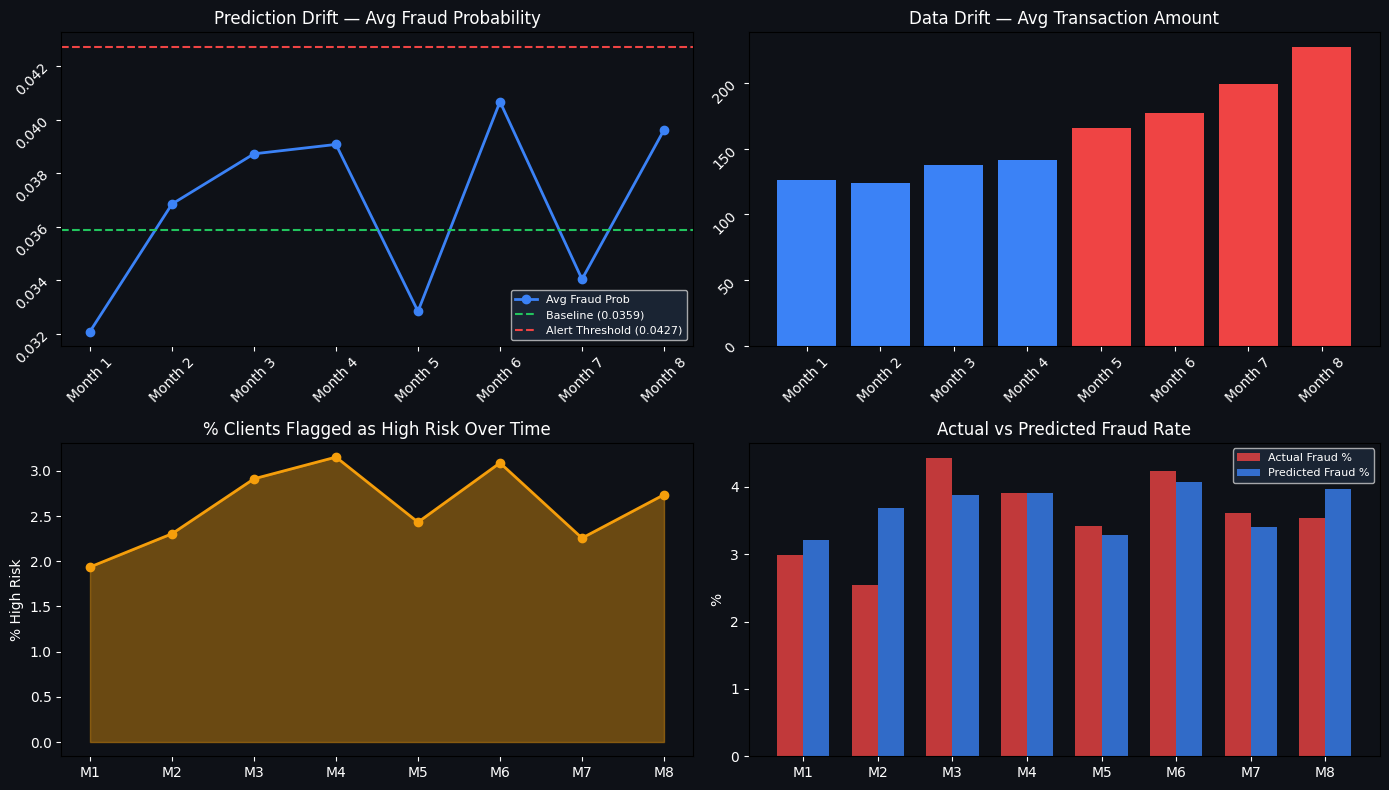


🔍 Drift Analysis Report:
Baseline (Months 1-3): 0.0359 ± 0.0034
Alert threshold: 0.0427

  Month 1: 0.0321 — ✅ Normal
  Month 2: 0.0369 — ✅ Normal
  Month 3: 0.0387 — ✅ Normal
  Month 4: 0.0391 — ✅ Normal
  Month 5: 0.0328 — ✅ Normal
  Month 6: 0.0407 — ✅ Normal
  Month 7: 0.0340 — ✅ Normal
  Month 8: 0.0396 — ✅ Normal

Recommendation: ✅ No significant drift detected — Model performing stably


In [7]:
# Drift Detection Visualization
# Flag windows where metrics deviate significantly from baseline

baseline_mean = drift_df['avg_fraud_prob'][:3].mean()
baseline_std = drift_df['avg_fraud_prob'][:3].std()
drift_threshold = baseline_mean + 2 * baseline_std  # 2 standard deviations = statistical alert

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.patch.set_facecolor('#0e1117')

months = drift_df['month']

# Plot 1 — Fraud Probability Drift
ax1 = axes[0, 0]
ax1.plot(months, drift_df['avg_fraud_prob'], 
         'o-', color='#3b82f6', linewidth=2, label='Avg Fraud Prob')
ax1.axhline(y=baseline_mean, color='#22c55e', 
            linestyle='--', label=f'Baseline ({baseline_mean:.4f})')
ax1.axhline(y=drift_threshold, color='#ef4444', 
            linestyle='--', label=f'Alert Threshold ({drift_threshold:.4f})')

# Highlight drifted windows
for i, row in drift_df.iterrows():
    if row['avg_fraud_prob'] > drift_threshold:
        ax1.axvspan(i-0.3, i+0.3, alpha=0.2, color='#ef4444')
        ax1.annotate('⚠ DRIFT', xy=(i, row['avg_fraud_prob']),
                    fontsize=8, color='#ef4444', ha='center')

ax1.set_title('Prediction Drift — Avg Fraud Probability', color='white')
ax1.set_facecolor('#0e1117')
ax1.tick_params(colors='white', rotation=45)
ax1.legend(facecolor='#1e293b', labelcolor='white', fontsize=8)
ax1.yaxis.label.set_color('white')

# Plot 2 — Transaction Amount Drift (Data Drift)
ax2 = axes[0, 1]
ax2.bar(months, drift_df['avg_transaction_amt'], 
        color=['#ef4444' if i >= 4 else '#3b82f6' for i in range(n_windows)])
ax2.set_title('Data Drift — Avg Transaction Amount', color='white')
ax2.set_facecolor('#0e1117')
ax2.tick_params(colors='white', rotation=45)

# Plot 3 — High Risk % over time
ax3 = axes[1, 0]
ax3.fill_between(range(n_windows), drift_df['pct_high_risk'] * 100, 
                  alpha=0.4, color='#f59e0b')
ax3.plot(range(n_windows), drift_df['pct_high_risk'] * 100,
         'o-', color='#f59e0b', linewidth=2)
ax3.set_title('% Clients Flagged as High Risk Over Time', color='white')
ax3.set_ylabel('% High Risk', color='white')
ax3.set_xticks(range(n_windows))
ax3.set_xticklabels([f'M{i+1}' for i in range(n_windows)])
ax3.set_facecolor('#0e1117')
ax3.tick_params(colors='white')

# Plot 4 — Actual vs Predicted Fraud Rate
ax4 = axes[1, 1]
x = range(n_windows)
width = 0.35
ax4.bar([i - width/2 for i in x], drift_df['fraud_rate'] * 100, 
        width, label='Actual Fraud %', color='#ef4444', alpha=0.8)
ax4.bar([i + width/2 for i in x], drift_df['avg_fraud_prob'] * 100, 
        width, label='Predicted Fraud %', color='#3b82f6', alpha=0.8)
ax4.set_title('Actual vs Predicted Fraud Rate', color='white')
ax4.set_ylabel('%', color='white')
ax4.set_xticks(x)
ax4.set_xticklabels([f'M{i+1}' for i in range(n_windows)])
ax4.legend(facecolor='#1e293b', labelcolor='white', fontsize=8)
ax4.set_facecolor('#0e1117')
ax4.tick_params(colors='white')
ax4.yaxis.label.set_color('white')

plt.tight_layout()
plt.savefig('../data/drift_monitor.png', dpi=150, bbox_inches='tight')
plt.show()

# Print drift alerts
print("\n🔍 Drift Analysis Report:")
print(f"Baseline (Months 1-3): {baseline_mean:.4f} ± {baseline_std:.4f}")
print(f"Alert threshold: {drift_threshold:.4f}")
print()
for _, row in drift_df.iterrows():
    status = "🔴 DRIFT DETECTED" if row['avg_fraud_prob'] > drift_threshold else "✅ Normal"
    print(f"  {row['month']}: {row['avg_fraud_prob']:.4f} — {status}")

print(f"\nRecommendation: ", end="")
drifted = (drift_df['avg_fraud_prob'] > drift_threshold).sum()
if drifted >= 2:
    print(f"⚠️  {drifted} windows show drift — MODEL RETRAINING RECOMMENDED")
elif drifted == 1:
    print("⚠️  1 window shows drift — Monitor closely, consider retraining")
else:
    print("✅ No significant drift detected — Model performing stably")